# Mini Projet Final

Analysez le dataset indicateurs socio-économiques de A à Z.


Partie 1

In [10]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('indicateurs_socio_economiques.csv')
print(df.head())

# A COMPLETER: Nettoyage, EDA, hypothèses, modélisation, conclusions


        pays  annee  pib_par_habitant  taux_chomage  taux_scolarisation  \
0     Italie   2023           42635.0           3.2                91.8   
1     Italie   2021           41099.0           8.6                94.0   
2  Allemagne   2020           44266.0           3.3                95.4   
3    Espagne   2022           45637.0          13.8                92.7   
4    Pologne   2022           34062.0          13.5                96.8   

   densite_population  depenses_sante_pourcent  esperance_vie  
0                95.3                      9.8           77.8  
1               273.6                      9.1           80.7  
2               425.4                     10.6           85.0  
3               465.6                      9.2           82.3  
4               437.9                      8.7           82.3  


In [11]:
print(f"Nombre de lignes : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")
print(f"\nTypes de données :\n{df.dtypes}")
print(df.isnull().sum())


Nombre de lignes : 500
Nombre de colonnes : 8

Types de données :
pays                        object
annee                        int64
pib_par_habitant           float64
taux_chomage               float64
taux_scolarisation         float64
densite_population         float64
depenses_sante_pourcent    float64
esperance_vie              float64
dtype: object
pays                       0
annee                      0
pib_par_habitant           0
taux_chomage               0
taux_scolarisation         0
densite_population         0
depenses_sante_pourcent    0
esperance_vie              0
dtype: int64


In [12]:
print(df.isnull().sum())
nb_doublons = df.duplicated().sum()
print("Nombre de doublons exacts :", nb_doublons)


pays                       0
annee                      0
pib_par_habitant           0
taux_chomage               0
taux_scolarisation         0
densite_population         0
depenses_sante_pourcent    0
esperance_vie              0
dtype: int64
Nombre de doublons exacts : 0


Partie 2

In [13]:
df.describe()


,annee,pib_par_habitant,taux_chomage,taux_scolarisation,densite_population,depenses_sante_pourcent,esperance_vie
count,500.00000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,2021.49600,35288.210000,9.18460,91.558400,271.518800,9.997000,79.876600
std,1.08828,7517.019974,3.55816,3.774887,128.949556,1.122788,2.868793
min,2020.00000,15364.000000,3.00000,85.000000,52.000000,8.000000,70.000000
25%,2021.00000,30124.250000,5.90000,88.200000,152.950000,9.000000,78.100000
50%,2022.00000,35015.500000,9.40000,91.400000,280.150000,10.000000,79.800000
75%,2022.00000,40186.750000,12.30000,94.725000,380.975000,10.900000,81.800000
max,2023.00000,60118.000000,14.90000,98.000000,499.800000,12.000000,85.000000


In [14]:
correlation_matrix = df.select_dtypes(include=['number']).corr()
print(correlation_matrix)

                            annee  pib_par_habitant  taux_chomage  \
annee                    1.000000         -0.062196      0.022626   
pib_par_habitant        -0.062196          1.000000      0.026981   
taux_chomage             0.022626          0.026981      1.000000   
taux_scolarisation      -0.023651          0.036178     -0.069884   
densite_population       0.066446         -0.003820     -0.025181   
depenses_sante_pourcent  0.027297          0.034310      0.030969   
esperance_vie           -0.048396          0.107256     -0.025615   

                         taux_scolarisation  densite_population  \
annee                             -0.023651            0.066446   
pib_par_habitant                   0.036178           -0.003820   
taux_chomage                      -0.069884           -0.025181   
taux_scolarisation                 1.000000            0.032831   
densite_population                 0.032831            1.000000   
depenses_sante_pourcent           -0.030801  

<Figure size 600x400 with 0 Axes>

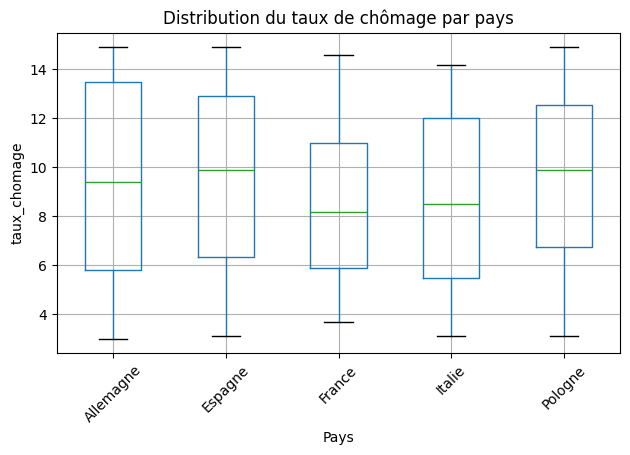

<Figure size 600x400 with 0 Axes>

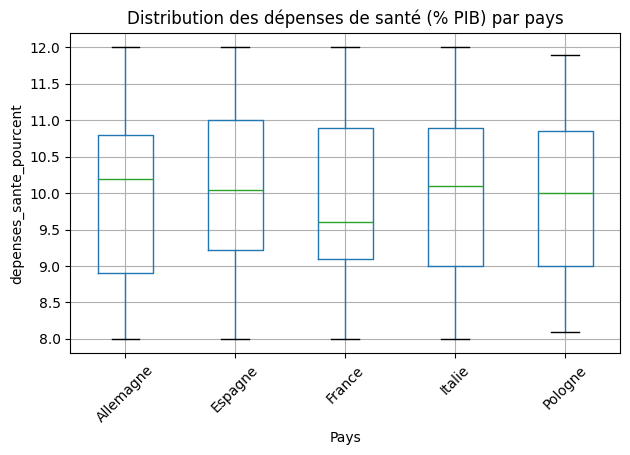

<Figure size 600x400 with 0 Axes>

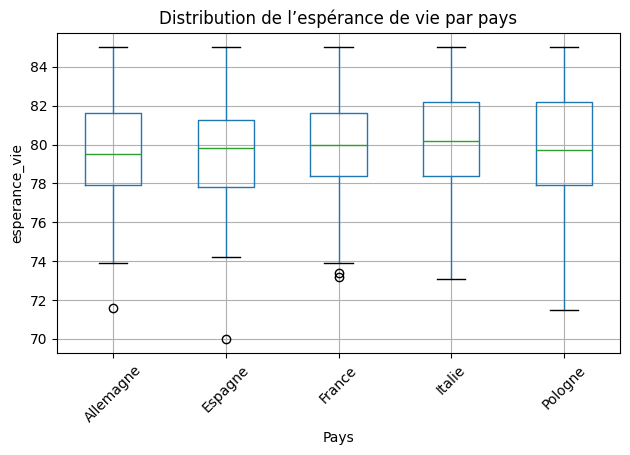

<Figure size 600x400 with 0 Axes>

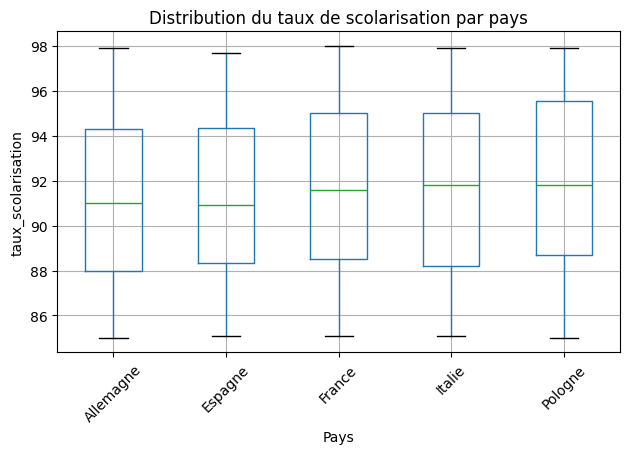

<Figure size 600x400 with 0 Axes>

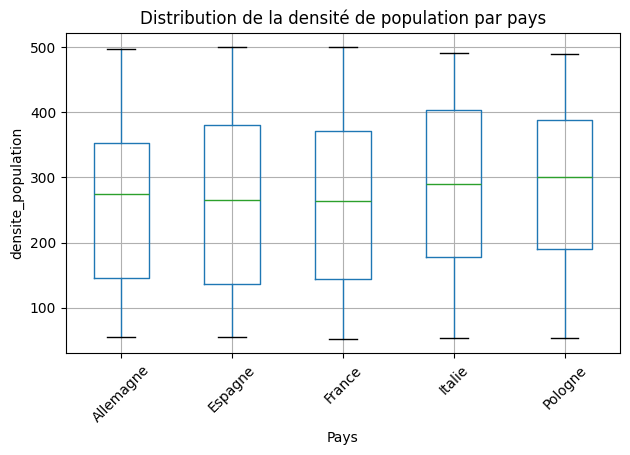

In [15]:
variables = [
    "taux_chomage",
    "depenses_sante_pourcent",
    "esperance_vie",
    "taux_scolarisation",
    "densite_population"
]

titles = {
    "taux_chomage": "Distribution du taux de chômage par pays",
    "depenses_sante_pourcent": "Distribution des dépenses de santé (% PIB) par pays",
    "esperance_vie": "Distribution de l’espérance de vie par pays",
    "taux_scolarisation": "Distribution du taux de scolarisation par pays",
    "densite_population": "Distribution de la densité de population par pays"
}

for var in variables:
    plt.figure(figsize=(6,4))
    df.boxplot(column=var, by="pays", rot=45)
    plt.title(titles[var])
    plt.suptitle("")
    plt.xlabel("Pays")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

Partie 3

Hypothèse 1 : Les pays présentant un PIB par habitant plus élevé tendent à avoir une espérance de vie plus importante, en raison d’un meilleur accès aux soins, à la nutrition et aux infrastructures sanitaires.

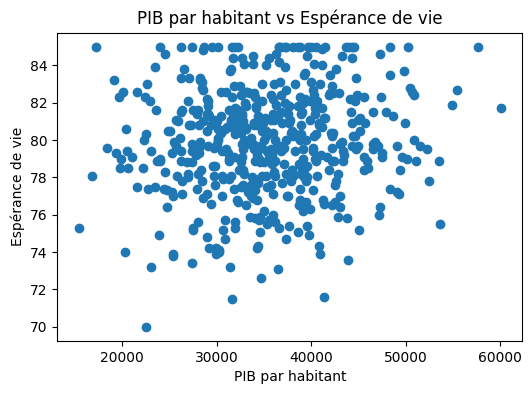

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df["pib_par_habitant"], df["esperance_vie"])
plt.xlabel("PIB par habitant")
plt.ylabel("Espérance de vie")
plt.title("PIB par habitant vs Espérance de vie")
plt.show()


Hypothèse 2 : L’espérance de vie varie selon les pays en raison de différences structurelles (systèmes de santé, modes de vie, environnement, démographie).

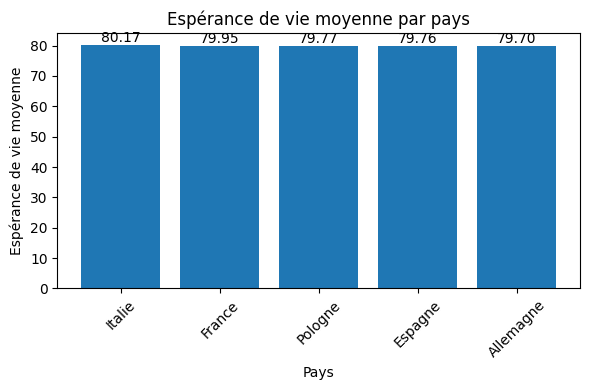

In [23]:
life_by_country = df.groupby("pays")["esperance_vie"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(life_by_country.index, life_by_country.values)

ax.set_xlabel("Pays")
ax.set_ylabel("Espérance de vie moyenne")
ax.set_title("Espérance de vie moyenne par pays")
plt.xticks(rotation=45)

# Ajouter la valeur au-dessus de chaque barre
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


Hypothèse 3 : Un taux de chômage plus élevé est lié à une diminution de l’espérance de vie, du fait de conditions de vie plus précaires et d’un accès réduit aux soins.

C:\Users\soupr\AppData\Local\Temp\ipykernel_3748\440176863.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


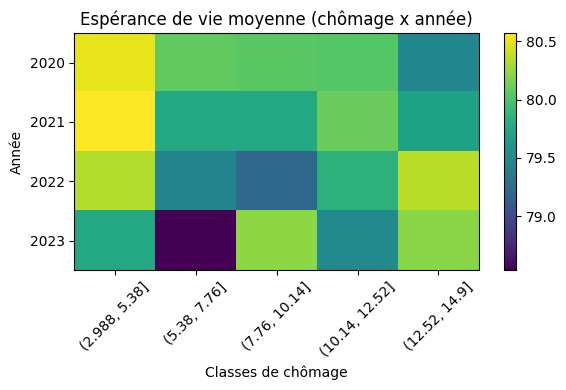

In [24]:

pivot = df.pivot_table(
    values="esperance_vie",
    index="annee",
    columns=pd.cut(df["taux_chomage"], bins=5),
    aggfunc="mean"
)

plt.figure(figsize=(6,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns.astype(str), rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("Classes de chômage")
plt.ylabel("Année")
plt.title("Espérance de vie moyenne (chômage x année)")
plt.colorbar()
plt.tight_layout()
plt.show()

Partie 4

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop(columns=['esperance_vie', 'pays'])
y = df['esperance_vie']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Performance - Régression Linéaire")
print("RMSE :", rmse)
print("R² :", r2)


Performance - Régression Linéaire
RMSE : 2.791808217314826
R² : 0.00775064244878787


In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

model = LinearRegression()
model1 = XGBRegressor()
model2 = RandomForestRegressor()

kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []
scores1 = []
scores2 = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)
    model1.fit(X_train, y_train)
    model2.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    y_pred1 = model1.predict(X_test)
    y_pred2 = model2.predict(X_test)

    score = r2_score(y_test, y_pred)
    score1 = r2_score(y_test, y_pred1)
    score2 = r2_score(y_test, y_pred2)

    scores.append(score)
    scores1.append(score1)
    scores2.append(score2)

scores = np.array(scores)
scores1 = np.array(scores1)
scores2 = np.array(scores2)

print("Scores Régression Linéaire :", scores)
print("Moyenne CV score Régression Linéaire:", np.mean(scores))
print("Ecart-type Régression Linéaire:", np.std(scores))

print("Scores  XGBRegressor:", scores1)
print("Moyenne CV score  XGBRegressor:", np.mean(scores1))
print("Ecart-type XGBRegressor:", np.std(scores1))

print("Scores RandomForestRegressor :", scores2)
print("Moyenne CV score RandomForestRegressor :", np.mean(scores2))
print("Ecart-type RandomForestRegressor :", np.std(scores2))

Scores Régression Linéaire : [ 0.0169745   0.01445794  0.00449542 -0.07773029 -0.0215638  -0.06012641
 -0.13470281 -0.00865302 -0.01474824  0.03017538]
Moyenne CV score Régression Linéaire: -0.02514213298047312
Ecart-type Régression Linéaire: 0.04864778701189259
Scores  XGBRegressor: [-0.15676263 -0.10480185 -0.30365866 -1.24189011 -0.45123482 -0.42698609
 -0.27773382 -0.19012307 -0.79581491 -0.4582187 ]
Moyenne CV score  XGBRegressor: -0.4407224659444463
Ecart-type XGBRegressor: 0.3271380806814993
Scores RandomForestRegressor : [ 0.11466237 -0.05521622 -0.13160908 -0.60118168 -0.20810966 -0.07510349
 -0.18538914 -0.01275785 -0.32360603 -0.15761498]
Moyenne CV score RandomForestRegressor : -0.16359257567868768
Ecart-type RandomForestRegressor : 0.18448760105947898


Partie 5

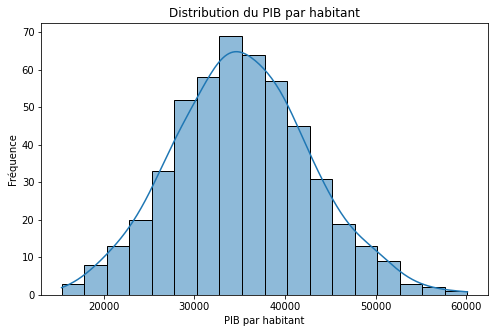

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['pib_par_habitant'], kde=True)
plt.title("Distribution du PIB par habitant")
plt.xlabel("PIB par habitant")
plt.ylabel("Fréquence")
plt.show()


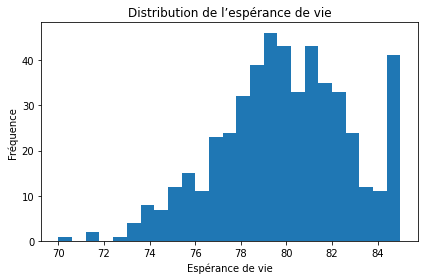

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["esperance_vie"], bins=25)
plt.xlabel("Espérance de vie")
plt.ylabel("Fréquence")
plt.title("Distribution de l’espérance de vie")
plt.tight_layout()
plt.show()


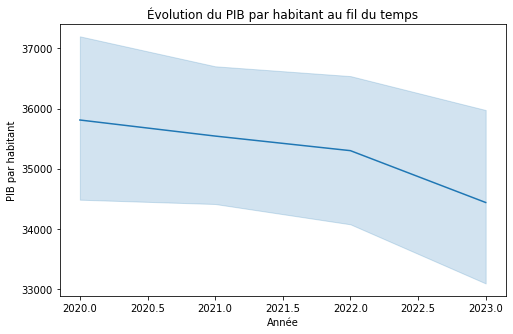

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x='annee',
    y='pib_par_habitant'
)
plt.title("Évolution du PIB par habitant au fil du temps")
plt.xlabel("Année")
plt.ylabel("PIB par habitant")
plt.show()
